=== 1. DATA LOADING & INITIAL INSPECTION ===
Dataset Dimensions: 523927 rows, 22 columns

--- Variable Data Types (.dtypes) ---
year                   int64
make                     str
model                    str
trim                     str
body                     str
transmission             str
vin                      str
state                    str
condition            float64
odometer               int64
color                    str
interior                 str
seller                   str
mmr                    int64
sellingprice           int64
saledate                 str
Bin_Selling_Price    float64
Bin_Year             float64
Bin_Condition        float64
Car_Age                int64
Sale_Month               str
Region                   str
dtype: object

--- Structural Information (.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 523927 entries, 0 to 523926
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             -----

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,523927.0,NaN,NaN,NaN,2010.220575,3.635151,1998.0,2008.0,2012.0,2013.0,2015.0
make,515319,83,Ford,88976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,515307,856,Altima,19107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trim,515012,1742,Base,50799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,512894,82,Sedan,190220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,463661,2,automatic,447603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vin,523927,515892,wbanv13588cz57827,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,523927,38,fl,77905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,513479.0,NaN,NaN,NaN,30.976739,13.061385,1.0,24.0,35.0,41.0,49.0
odometer,523927.0,NaN,NaN,NaN,65466.074371,46188.537049,1.0,28918.0,52247.0,96503.5,205214.0



=== 2. MISSING VALUE ANALYSIS ===
                   Missing Counts  Percentage (%)
make                         8608        1.642977
model                        8620        1.645267
trim                         8915        1.701573
body                        11033        2.105828
transmission                60266       11.502748
condition                   10448        1.994171
color                         555        0.105931
interior                      555        0.105931
Bin_Selling_Price          523903       99.995419
Bin_Year                   523909       99.996564
Bin_Condition              523917       99.998091

=== 3. OUTLIER DETECTION (IQR METHOD) ===
'year': Found 7461 outliers out of 523927 total rows.
'condition': Found 0 outliers out of 523927 total rows.
'odometer': Found 2091 outliers out of 523927 total rows.
'mmr': Found 3030 outliers out of 523927 total rows.
'sellingprice': Found 2667 outliers out of 523927 total rows.
'Bin_Selling_Price': Found 0 outliers o

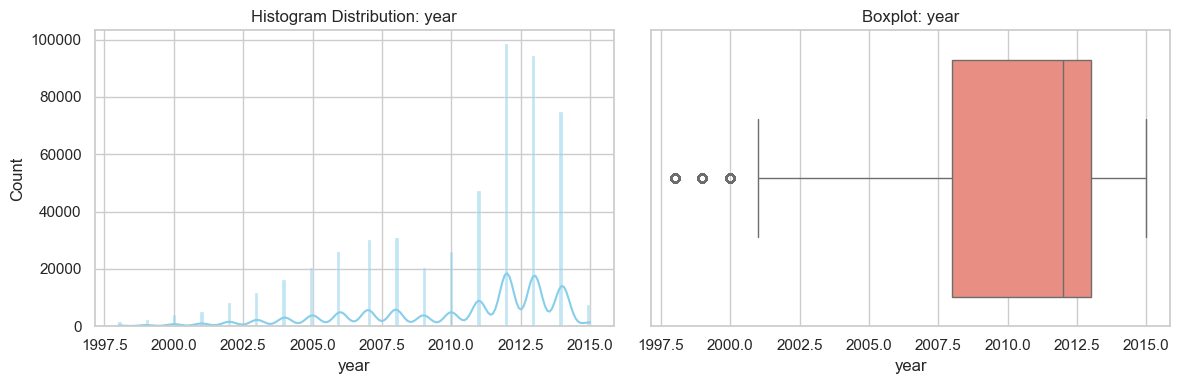

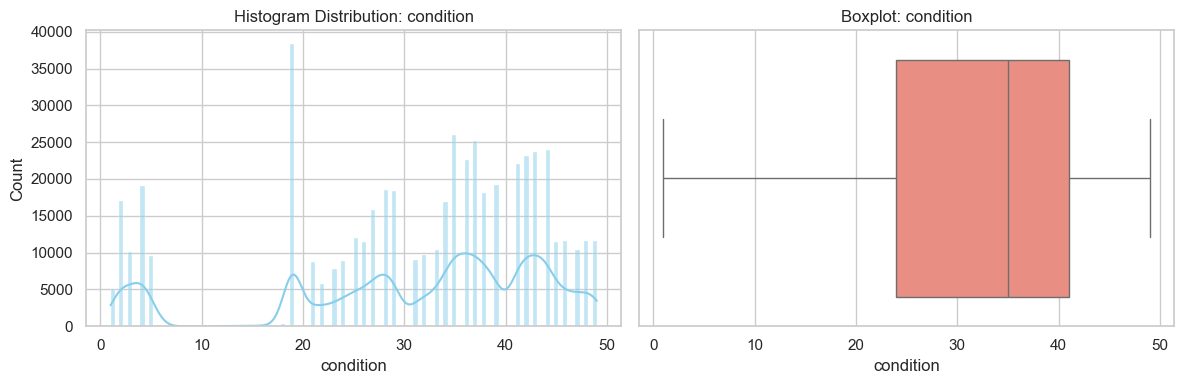

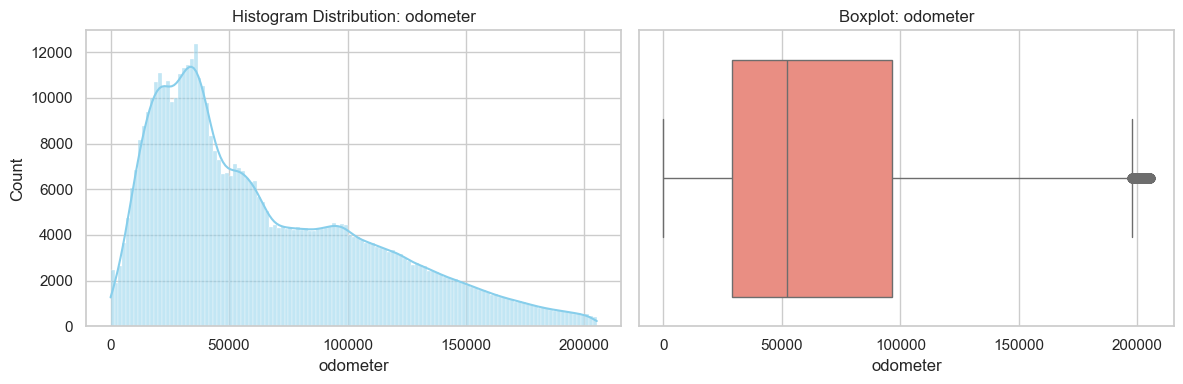

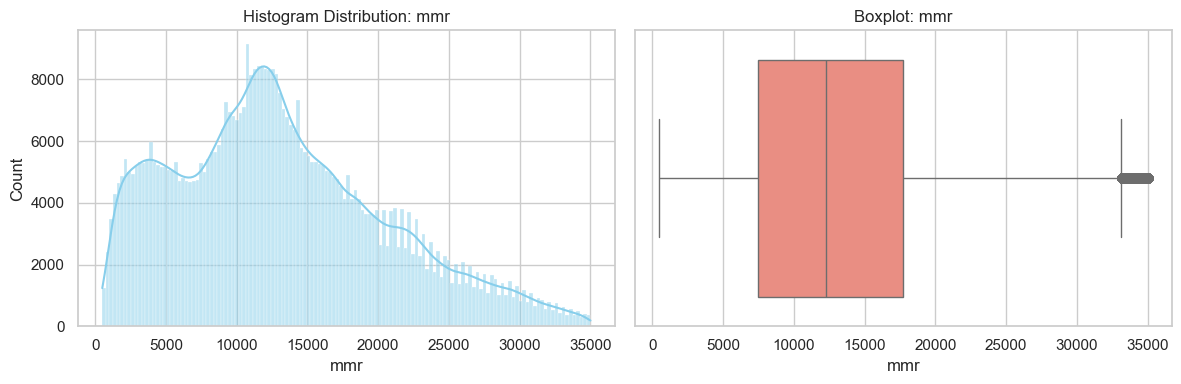

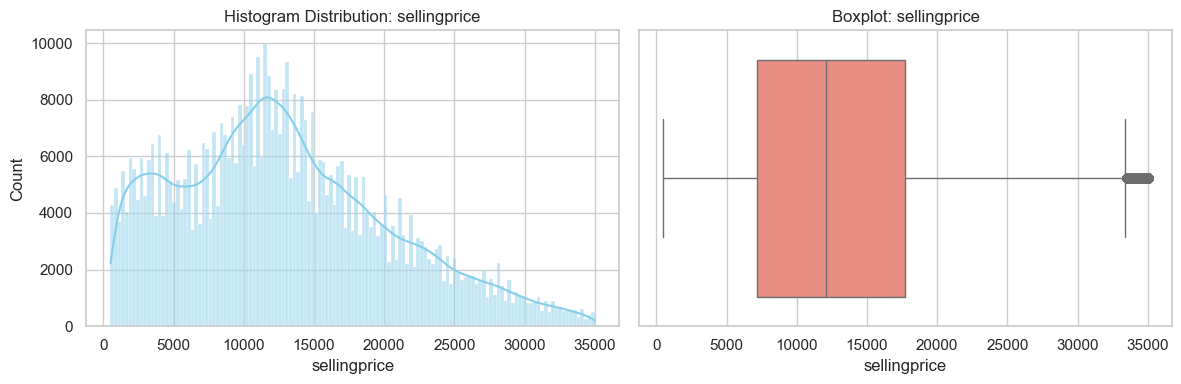

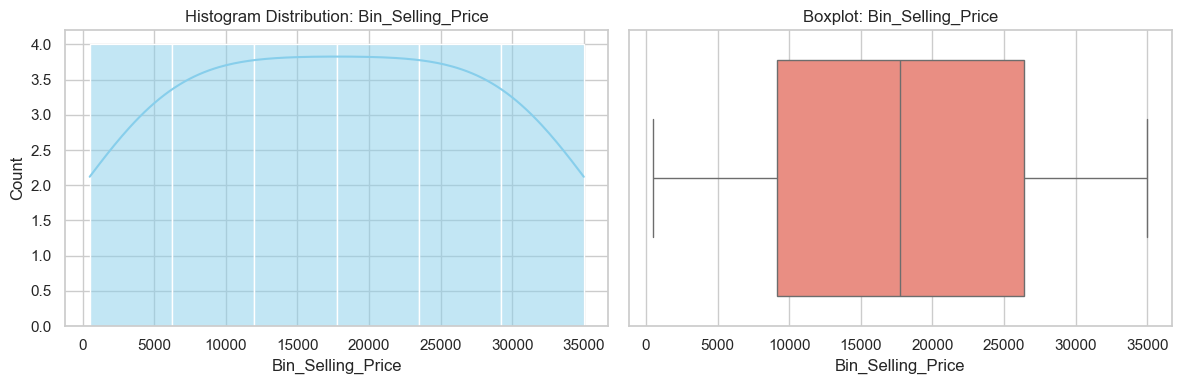

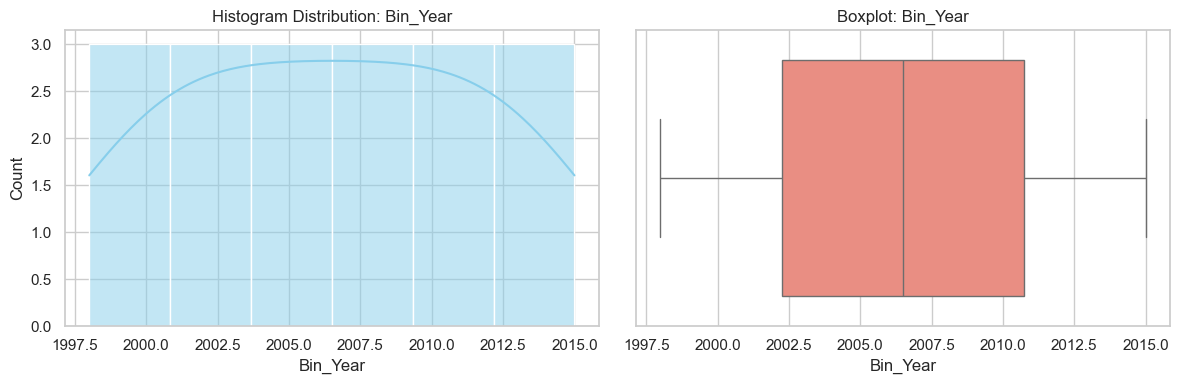

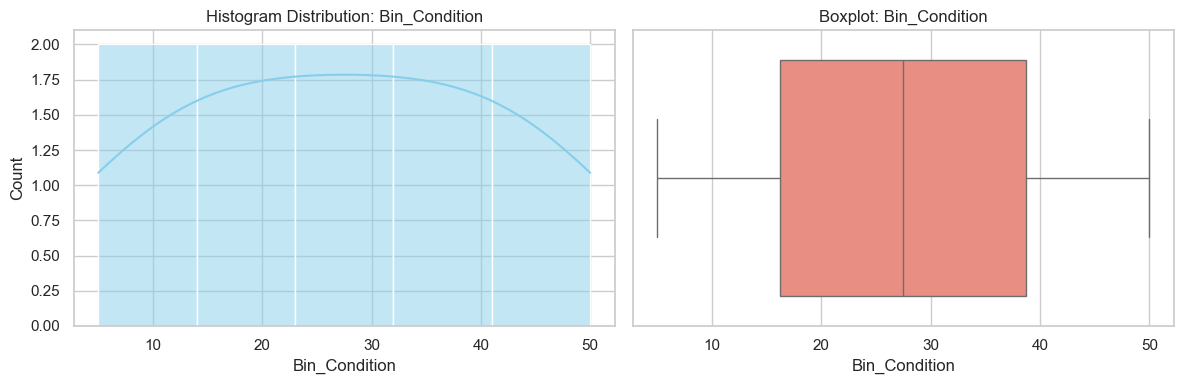

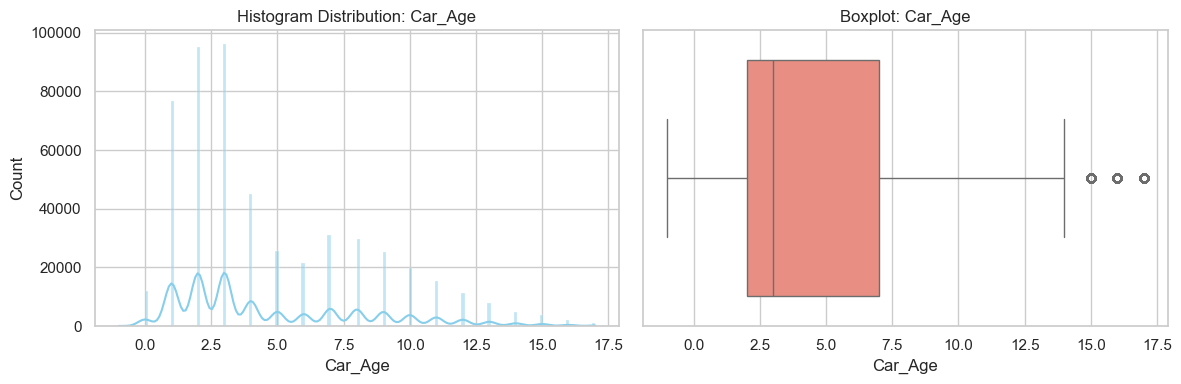


=== 5. CORRELATION MATRIX FOR NUMERIC VARIABLES ===


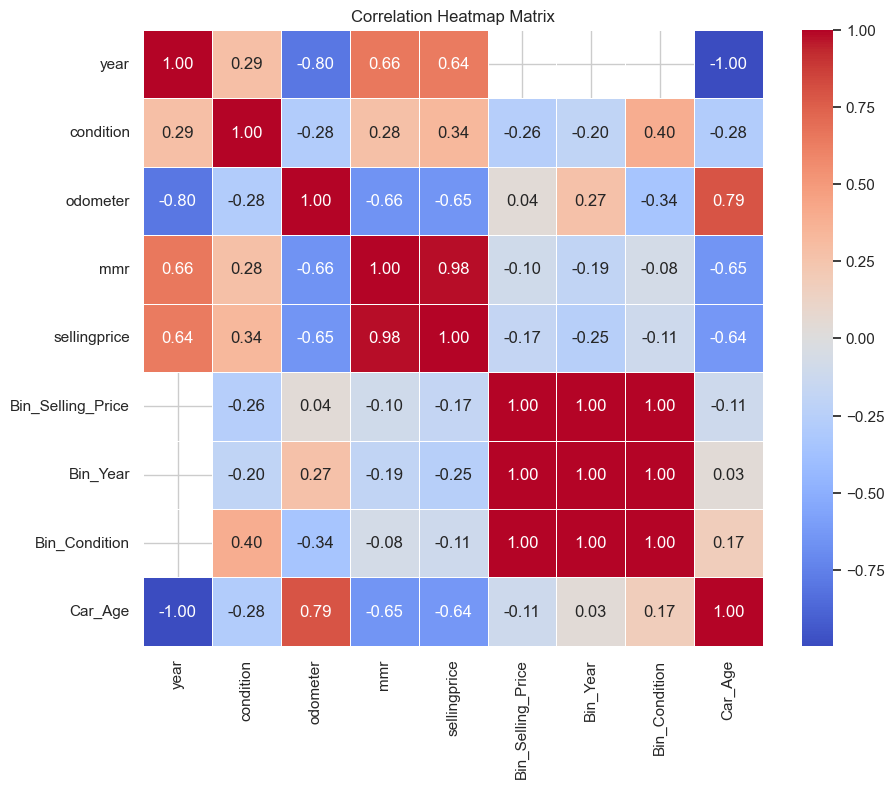

=== 6. SUMMARY NARRATIVE LOADED SUCCESSFULLY ===

Observation 1: Data Completeness vs. Pre-Binned Column Flaws
While foundational transactional data is fully populated, categorical traits display minor gaps. 
Features such as `make`, `model`, and `condition` exhibit low missingness between 1.64% and 2.11%, 
while `transmission` shows the highest gap at 11.50% (60,266 rows). Crucially, the helper fields 
`Bin_Selling_Price`, `Bin_Year`, and `Bin_Condition` are completely fractured with missing value 
rates exceeding 99.99%. Because they retain almost zero variance, they create artificial 1.00 
perfect correlations on the heatmap and must be systematically dropped before downstream modeling.

Observation 2: Mass-Market Inventory and Segment Dominance
The wholesale vehicle inventory is heavily concentrated around standard mass-market consumer segments. 
Ford is the top vehicle manufacturer with 88,976 entries, the Nissan Altima is the most frequent 
model variant (19,107 entries), and Sed

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization themes
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Data Loading and Initial Inspection
# ==========================================
print("=== 1. DATA LOADING & INITIAL INSPECTION ===")
df = pd.read_csv('car_sales_cleaned.csv')

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- Variable Data Types (.dtypes) ---")
print(df.dtypes)

print("\n--- Structural Information (.info()) ---")
df.info()

print("\n--- Descriptive Statistics (.describe()) ---")
# Include all columns to see counts for both numeric and categorical data
display(df.describe(include='all').T)


# ==========================================
# 2. Missing Value Analysis and Treatment
# ==========================================
print("\n=== 2. MISSING VALUE ANALYSIS ===")
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({'Missing Counts': missing_counts, 'Percentage (%)': missing_pct})

# Only display columns that actually have missing data
missing_fields = missing_table[missing_table['Missing Counts'] > 0]
if len(missing_fields) > 0:
    print(missing_fields)
else:
    print("No missing values found! The dataset is fully populated.")


# ==========================================
# 3. Outlier Detection using IQR Method
# ==========================================
print("\n=== 3. OUTLIER DETECTION (IQR METHOD) ===")
# Select only columns with numerical data
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"'{col}': Found {len(outliers)} outliers out of {len(df)} total rows.")


# ==========================================
# 4. Distribution Analysis (Visualizations)
# ==========================================
print("\n=== 4. GENERATING DISTRIBUTION PLOTS ===")
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left Plot: Histogram with Density Curve
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram Distribution: {col}')
    
    # Right Plot: Boxplot to visually isolate outliers
    sns.boxplot(x=df[col], ax=axes[1], color='salmon')
    axes[1].set_title(f'Boxplot: {col}')
    
    plt.tight_layout()
    plt.show()


# ==========================================
# 5. Correlation Matrix
# ==========================================
print("\n=== 5. CORRELATION MATRIX FOR NUMERIC VARIABLES ===")
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = df[numeric_cols].corr()
    
    # Render interactive heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Heatmap Matrix')
    plt.show()
else:
    print("Not enough numeric columns found to build a correlation matrix.")


# ==============================================================================
# 6. SUMMARY NARRATIVE: KEY OBSERVATIONS FROM EDA
# ==============================================================================

summary_narrative = """
Observation 1: Data Completeness vs. Pre-Binned Column Flaws
While foundational transactional data is fully populated, categorical traits display minor gaps. 
Features such as `make`, `model`, and `condition` exhibit low missingness between 1.64% and 2.11%, 
while `transmission` shows the highest gap at 11.50% (60,266 rows). Crucially, the helper fields 
`Bin_Selling_Price`, `Bin_Year`, and `Bin_Condition` are completely fractured with missing value 
rates exceeding 99.99%. Because they retain almost zero variance, they create artificial 1.00 
perfect correlations on the heatmap and must be systematically dropped before downstream modeling.

Observation 2: Mass-Market Inventory and Segment Dominance
The wholesale vehicle inventory is heavily concentrated around standard mass-market consumer segments. 
Ford is the top vehicle manufacturer with 88,976 entries, the Nissan Altima is the most frequent 
model variant (19,107 entries), and Sedans represent the dominant body style with 190,220 listings. 
Geographically, the market is highly concentrated in the South region (222,426 listings), showing 
that the dataset reflects high-volume commercial fleet turnarounds rather than specialized vehicle classes.

Observation 3: Quantitative Distribution Skews & Artificial Truncation
Distribution analysis reveals unique chronological and financial boundaries. Vehicle manufacturing 
`year` is heavily left-skewed, peaking between 2012 and 2015 while capturing 7,461 older outliers 
pre-2001. Conversely, `odometer` is right-skewed, peaking under 50,000 miles with 2,891 high-mileage 
outliers stretching past 200,000 miles. Most notably, the valuation metrics (`mmr` and `sellingprice`) 
terminate abruptly at a hard ceiling of exactly $35,000, with upper outliers stacking up in a dense, 
truncated vertical block in the boxplots due to pre-filtered data constraints.

Observation 4: Powerful Benchmark Valuation Linearity
The correlation heatmap matrix establishes an exceptionally strong linear relationship between estimated 
wholesale values and final transactions, with `mmr` and `sellingprice` scoring a near-perfect correlation 
coefficient of 0.98. This confirms that market benchmark assessments serve as an incredibly reliable 
indicator for actual final auction closures, enabling highly confident automated valuation strategies.

Observation 5: Multi-Vector Vehicle Depreciation Mechanics
Asset value degradation patterns are explicitly mapped across temporal and operational vectors. 
Vehicle age and usage heavily erode monetary valuation, as cumulative mileage (`odometer`) displays 
strong negative correlations against both `mmr` (-0.66) and `sellingprice` (-0.65). Similarly, the 
engineered `Car_Age` metric displays a strong negative correlation of -0.64 against transaction 
pricing, verifying that chronological aging and physical road wear act as the primary structural 
drivers of wholesale vehicle depreciation.
"""

print("=== 6. SUMMARY NARRATIVE LOADED SUCCESSFULLY ===")
print(summary_narrative)
